In [1]:
import sqlite3
import pandas as pd
from shelf_life.preprocessing import preprocess
import matplotlib.pyplot as plt
import plotly.express as px

In [2]:
conn = sqlite3.connect("../data/db/products.db")
df = pd.read_sql("SELECT * FROM product_details;", conn)

conn.close()

## Product stats

<class 'pandas.DataFrame'>
RangeIndex: 8742 entries, 0 to 8741
Data columns (total 40 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     8742 non-null   int64  
 1   run_id                 8742 non-null   int64  
 2   country                8742 non-null   str    
 3   currency               8742 non-null   str    
 4   target_url             8742 non-null   str    
 5   full_product_url       8742 non-null   str    
 6   product_code           8742 non-null   str    
 7   loves_count            8742 non-null   int64  
 8   rating                 8728 non-null   float64
 9   reviews                8728 non-null   float64
 10  brand_source_id        8742 non-null   str    
 11  category_id            8742 non-null   str    
 12  category_name          8742 non-null   str    
 13  category_url           8742 non-null   str    
 14  sku_id                 8742 non-null   str    
 15  brand_name     

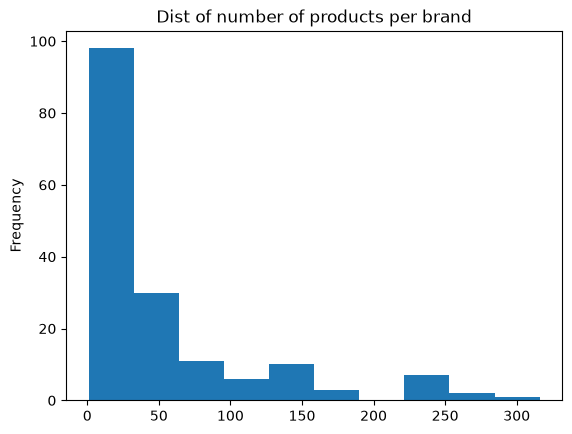


Unique brands: 168


In [3]:
print(df.info())
print('\nUnique skus per product code')
print(df.groupby('target_url')['sku_id'].nunique().describe())

print('\nBrand distribtion')
ax = df.brand_name.value_counts().plot(kind='hist',title='Dist of number of products per brand')
plt.show()
print(f"\nUnique brands: {df.brand_name.nunique()}")

In [4]:
df[df["variation_type"] == "Size"].groupby(
    ["brand_name", "product_code", "display_name", "variation_value", "size_refinement"]
).agg({"sku_id": "count", "price": "first"})

sku_id  \
brand_name              product_code display_name                                       variation_value               size_refinement           
AAVRANI                 P510710      Hair Density Boosting Scalp Serum for Thinning ... 2 oz / 60 ml - 4 Month Supply                       1   
                        P510713      Hair and Scalp Recovery Pre-Wash Oil for Streng... 1.7 oz                                              1   
                        P510718      Deep Conditioning Hair Mask for Dry, Damaged Hair  8.4 oz                                              1   
                        P513304      Jelly Clarifying Detox Shampoo for Scalp & Hair    8.4 oz / 250 ml                                     1   
Anastasia Beverly Hills P173317      Brow Primer Colorless Wax Pencil                   0.1 oz/ 2.5 mL                                      1   
...                                                                                                                                       ...   
stila                   P406281      Correct & Perfect All-In-One Color Correcting P... 0.45 oz./12.9 g                                     1   
tarte                   P387228      timeless™ smoothing & blurring face primer         0.5 oz/ 14.2 g                                      1   
                        P403812      tartelette™ in bloom Amazonian clay eyeshadow p... 12 x 0.046oz/12 x 1.3g                              1   
                        P444433      big ego™ lifting & volumizing mascara              0.15 oz/ 4.5 mL               Mini                  1   
                                                                                        0.23 fl oz/ 7 mL                                    1   

                                                                                                                                        price  
brand_name              product_code display_name                                       variation_value               size_refinement          
AAVRANI                 P510710      Hair Density Boosting Scalp Serum for Thinning ... 2 oz / 60 ml - 4 Month Supply                  $69.50  
                        P510713      Hair and Scalp Recovery Pre-Wash Oil for Streng... 1.7 oz                                         $51.00  
                        P510718      Deep Conditioning Hair Mask for Dry, Damaged Hair  8.4 oz                                         $59.00  
                        P513304      Jelly Clarifying Detox Shampoo for Scalp & Hair    8.4 oz / 250 ml                                $51.00  
Anastasia Beverly Hills P173317      Brow Primer Colorless Wax Pencil                   0.1 oz/ 2.5 mL                                 $28.50  
...                                                                                                                                       ...  
stila                   P406281      Correct & Perfect All-In-One Color Correcting P... 0.45 oz./12.9 g                                $59.00  
tarte                   P387228      timeless™ smoothing & blurring face primer         0.5 oz/ 14.2 g                                 $57.00  
                        P403812      tartelette™ in bloom Amazonian clay eyeshadow p... 12 x 0.046oz/12 x 1.3g                         $68.00  
                        P444433      big ego™ lifting & volumizing mascara              0.15 oz/ 4.5 mL               Mini             $21.00  
                                                                                        0.23 fl oz/ 7 mL                               $38.00  

[1765 rows x 2 columns]

In [5]:
df = preprocess(df)


df['categories'] = df['category_name'].str.split(' --- ').to_list()
n_cats=3
df['categories'] = df['categories'].apply(lambda x: ['']*(n_cats-len(x))+x)
print(df['categories'].apply(len).min())

df = pd.concat(
    [
        df,
        pd.DataFrame(df['categories'].to_list(), columns=['cat_l3', 'cat_l2', 'cat_l1'])
    ],
    axis=1
)
df.drop('categories', inplace=True, axis=1)

3


In [6]:
# how many are missing a size?
df[df['size'].isna()]
df[df['size']==""]['category_name'].value_counts()
# +300 product codes missing size information
df[df['size']==""][['display_name', 'full_product_url']].head()

# need to update preproccessing script, assume oz is floz if ml is present 

,display_name,full_product_url
113,"DIPBROW® Waterproof, Smudge-Proof Brow Pomade",https://www.sephora.com/product/dipbrow-pomade...
116,"DIPBROW® Waterproof, Smudge-Proof Brow Pomade",https://www.sephora.com/product/dipbrow-pomade...
118,"DIPBROW® Waterproof, Smudge-Proof Brow Pomade",https://www.sephora.com/product/dipbrow-pomade...
175,Brow Powder Duo Dual-Shade Fill & Define,https://www.sephora.com/product/brow-powder-du...
185,"Brow Definer 3-in-1 Easy Define, Fill, & Detai...",https://www.sephora.com/product/brow-definer-P...


In [10]:
df[['product_code', 'display_name', 'price','size','type','size_oz',
       'size_fl_oz', 'size_ml', 'size_g', 'size_phase', 'size_info',
       'price_per_oz', 'price_per_ml', 'price_per_g']]

,product_code,display_name,price,size,type,size_oz,size_fl_oz,size_ml,size_g,size_phase,size_info,price_per_oz,price_per_ml,price_per_g
0,P513304,Jelly Clarifying Detox Shampoo for Scalp & Hair,51.0,8.4 oz / 250 ml,Standard,8.4000,NaN,250.0,NaN,both,NaN,6.071429,0.204000,NaN
1,P510710,Hair Density Boosting Scalp Serum for Thinning...,69.5,2 oz / 60 ml - 4 Month Supply,Standard,2.0000,NaN,60.0,NaN,both,4 Month Supply,34.750000,1.158333,NaN
2,P510713,Hair and Scalp Recovery Pre-Wash Oil for Stren...,51.0,1.7 oz,Standard,1.7000,NaN,NaN,NaN,solid,NaN,30.000000,NaN,NaN
3,P510718,"Deep Conditioning Hair Mask for Dry, Damaged Hair",59.0,8.4 oz,Standard,8.4000,NaN,NaN,NaN,solid,NaN,7.023810,NaN,NaN
4,P503741,Hydrating Lip Treatment Oil,27.0,0.15 oz / 4.5 ml,Standard,0.1500,NaN,4.5,NaN,both,NaN,180.000000,6.000000,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8737,P443328,12H Intense Ink Brush Tip Liquid Liner,20.0,0.0135 oz/0.40 ml,Standard,0.0135,NaN,0.4,NaN,both,NaN,1481.481481,50.000000,NaN
8738,P44332878,Powder Puff Setting Brush 170,46.0,,Standard,NaN,NaN,NaN,NaN,unknown,NaN,NaN,NaN,NaN
8739,P443744,Rouge Essentiel Silky Cream Lipstick,57.0,,Standard,NaN,NaN,NaN,NaN,unknown,NaN,NaN,NaN,NaN
8740,P443790,Mini Pro Filt’r Instant Retouch Setting Powder,30.0,0.27 oz/ 7.8 g,Standard,0.2700,NaN,NaN,7.8,solid,NaN,111.111111,NaN,3.846154


In [11]:
df


,id,run_id,country,currency,target_url,full_product_url,product_code,loves_count,rating,reviews,...,size_ml,size_g,size_phase,size_info,price_per_oz,price_per_ml,price_per_g,cat_l3,cat_l2,cat_l1
0,1,1,CA,CAD,/product/aavrani-jelly-clarifying-detox-shampo...,https://www.sephora.com/product/aavrani-jelly-...,P513304,13855,4.5915,142.0,...,250.0,NaN,both,NaN,6.071429,0.204000,NaN,Shampoo,Shampoo & Conditioner,Hair
1,2,1,CA,CAD,/product/aavrani-hair-density-boosting-treatme...,https://www.sephora.com/product/aavrani-hair-d...,P510710,19613,4.3640,283.0,...,60.0,NaN,both,4 Month Supply,34.750000,1.158333,NaN,Scalp Treatments,Hair Styling & Treatments,Hair
2,3,1,CA,CAD,/product/aavrani-hair-scalp-recovery-oil-P510713,https://www.sephora.com/product/aavrani-hair-s...,P510713,6027,4.6396,111.0,...,NaN,NaN,solid,NaN,30.000000,NaN,NaN,Scalp Treatments,Hair Styling & Treatments,Hair
3,4,1,CA,CAD,/product/aavrani-intensive-repair-conditioning...,https://www.sephora.com/product/aavrani-intens...,P510718,6194,4.4295,149.0,...,NaN,NaN,solid,NaN,7.023810,NaN,NaN,Hair Masks,Hair Styling & Treatments,Hair
4,5,1,CA,CAD,/product/lip-treatment-oil-P503741,https://www.sephora.com/product/lip-treatment-...,P503741,87103,4.7176,262.0,...,4.5,NaN,both,NaN,180.000000,6.000000,NaN,Lip Oil,Lip,Makeup
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8737,9356,1,CA,CAD,/product/hot-line-brush-tip-liqud-liner-P443328,https://www.sephora.com/product/hot-line-brush...,P443328,63018,3.7653,1112.0,...,0.4,NaN,both,NaN,1481.481481,50.000000,NaN,Eyeliner,Eye,Makeup
8738,9357,1,CA,CAD,/product/powder-puff-setting-brush-170-P44332878,https://www.sephora.com/product/powder-puff-se...,P44332878,52177,4.4524,84.0,...,NaN,NaN,unknown,NaN,NaN,NaN,NaN,Face Brushes,Brushes & Applicators,Makeup
8739,9358,1,CA,CAD,/product/rouge-essentiel-silky-creme-lipstick-...,https://www.sephora.com/product/rouge-essentie...,P443744,73605,4.2231,121.0,...,NaN,NaN,unknown,NaN,NaN,NaN,NaN,Lipstick,Lip,Makeup
8740,9359,1,CA,CAD,/product/pro-filt-r-mini-instant-retouch-setti...,https://www.sephora.com/product/pro-filt-r-min...,P443790,152449,4.1753,502.0,...,NaN,7.8,solid,NaN,111.111111,NaN,3.846154,,Mini Size,Makeup


In [12]:
df.cat_l3.value_counts()

cat_l3
Foundation                           1350
Concealer                             898
Perfume                               584
Lipstick                              577
                                      429
                                     ... 
Hair Towels                             1
Lip Brushes                             1
Hair Tool Attachments & Diffusers       1
Scalp Massagers & Rollers               1
Facial Rollers                          1
Name: count, Length: 98, dtype: int64

<Axes: >

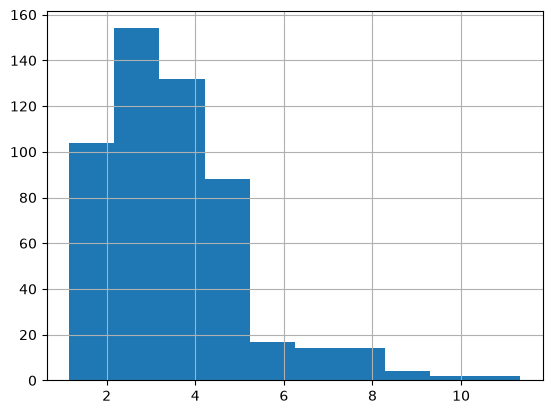

In [13]:
df[df['cat_l3']=='Perfume']['price_per_ml'].hist()

In [14]:
## l1_cat minisize might be separated from fullsize versions in other categories 
# need reliable way to link all versions of products when they may have diff product code+skus

In [15]:
perf_df = df[df['cat_l3']=='Perfume']

In [16]:
perf_df.groupby('product_code').agg({
    'size': 'unique',
    'type': 'unique',
    'price':'unique',
    'size_oz':'unique',
    'price_per_oz':'unique'
})

,size,type,price,size_oz,price_per_oz
product_code,,,,,
P136025,[1.6/50],[Standard],[136.5],[nan],[nan]
P144212,"[1.7 oz/ 50 mL, 2.5 oz/ 75 mL]",[Standard],"[152.0, 175.0]","[1.7, 2.5]","[89.41176470588236, 70.0]"
P163103,"[3 oz/ 90 mL, 1 oz/ 30 mL, 6.7 oz/ 198 mL, 0.3...",[Standard],"[165.0, 99.0, 229.0, 46.0, 139.0]","[3.0, 1.0, 6.7, 0.3, 1.7]","[55.0, 99.0, 34.179104477611936, 153.333333333..."
P183301,"[1.7oz/ 50mL, 0.33 oz/10 mL, 1 oz/ 30 mL, 3.4 ...",[Standard],"[215.0, 70.0, 156.0, 315.0]","[1.7, 0.33, 1.0, 3.4]","[126.47058823529412, 212.12121212121212, 156.0..."
P191858,"[3.3 oz / 100 ml, 0.33 oz / 10 mL, 1 oz, 1.6 o...",[Standard],"[178.0, 47.0, 104.0, 131.5]","[3.3, 0.33, 1.0, 1.6]","[53.939393939393945, 142.4242424242424, 104.0,..."
...,...,...,...,...,...
P509015,"[3.3 oz, 1.6 oz]",[Standard],"[218.5, 175.5]","[3.3, 1.6]","[66.21212121212122, 109.6875]"
P516183,"[3.3 OZ/100 ML, 1.7 OZ/50 ML, .33 OZ/10 ML, 1 ...",[Standard],"[190.0, 148.0, 49.0, 116.0, 257.0]","[3.3, 1.7, 0.33, 1.0, 6.7]","[57.57575757575758, 87.05882352941177, 148.484..."
P6430,"[3.4 oz / 100 mL, 0.67 oz/ 20 mL, 1.7 OZ / 50 ...",[Standard],"[234.0, 75.0, 171.0, 269.0, 125.0]","[3.4, 0.67, 1.7, 5.0, 1.0]","[68.82352941176471, 111.94029850746269, 100.58..."


In [20]:


plot_df = (
    perf_df
    .dropna(subset=['size_oz', 'price'])
    .drop_duplicates(subset=['product_code', 'size_oz', 'price'])
    .sort_values(['product_code', 'size_oz'])          # lines connect in size order
)
# only products with 2+ sizes are interesting as lines
plot_df = plot_df[plot_df.groupby('product_code')['size_oz'].transform('nunique') > 1]

fig = px.line(
    plot_df,
    x='size_oz', y='price',
    line_group='product_code',
    hover_name='display_name',                         # or 'product_code'
    hover_data={'brand_name': True, 'size': True, 'price_per_oz': ':.2f'},
    markers=True,
    # log_x=True, log_y=True,
    labels={'size_oz': 'Size (oz)', 'price': 'Price (CAD)'},
)
fig.update_traces(line=dict(color='rgba(100,100,100,0.25)', width=1),
                  marker=dict(size=5, color='rgba(31,119,180,0.7)'))
fig.update_layout(showlegend=False, template='simple_white')
fig.show()

In [19]:
import numpy as np

def slope(d):
    return np.polyfit(np.log(d.size_oz), np.log(d.price), 1)[0]

exps = (plot_df.groupby('product_code')
        .apply(slope)
        .rename('b')
        .reset_index()
        .merge(plot_df[['product_code', 'display_name', 'brand_name']].drop_duplicates('product_code')))

print(exps.b.describe())

fig = px.strip(exps, x='b', hover_name='display_name', hover_data=['brand_name'],
               labels={'b': 'Price exponent (1 = linear, <1 = volume discount)'})
fig.add_vline(x=1, line_dash='dash')
fig.update_layout(template='simple_white')
fig.show()

count    163.000000
mean       0.557969
std        0.151530
min        0.127397
25%        0.452984
50%        0.561919
75%        0.646957
max        1.042862
Name: b, dtype: float64
